Objectif

Personnaliser un CNN pré-entraîné (par ex. VGG16, ResNet ou MobileNet) pour créer un classificateur d’images personnalisé en utilisant soit l’extraction de caractéristiques, soit l’affinage (fine-tuning).


Instructions
1. Choisir un jeu de données personnalisé

Exemple : classer des images de fleurs, aliments, animaux, ou un jeu de données personnalisé de 2 à 5 classes

Optionnel : utiliser un jeu de données lié à votre domaine (ex. médical, agricole, etc.)


2. Charger un modèle pré-entraîné

Utiliser VGG16, ResNet50 ou un modèle similaire

Mettre include_top=False pour supprimer le classificateur original

Choisir soit :

Extraction de caractéristiques (geler toutes les couches)

Fine-tuning (débloquer les N dernières couches)


3. Ajouter une nouvelle tête de classification

Utiliser : GlobalAveragePooling2D → Dense → Dropout → Sortie (Softmax/Sigmoid)

Adapter la sortie au nombre de classes de votre jeu de données


4. Entraîner votre classificateur personnalisé

Entraînez et validez pendant environ 10 à 20 époques

Enregistrez la précision et la perte, et notez les signes de sous-apprentissage ou surapprentissage

In [8]:
# ── NETTOYAGE AVANT UPLOAD GITHUB ──────────────────────────
import json, glob, os

# Détecte automatiquement le fichier .ipynb dans /content
notebooks = glob.glob("/content/*.ipynb")

for nb_path in notebooks:
    with open(nb_path, "r", encoding="utf-8") as f:
        nb = json.load(f)

    # Supprime metadata.widgets (cause de l'erreur GitHub)
    if "widgets" in nb.get("metadata", {}):
        del nb["metadata"]["widgets"]
        print(f"✓ 'metadata.widgets' supprimé dans : {os.path.basename(nb_path)}")
    else:
        print(f"✓ Déjà propre : {os.path.basename(nb_path)}")

    with open(nb_path, "w", encoding="utf-8") as f:
        json.dump(nb, f, indent=1, ensure_ascii=False)

print("\n✓ Notebook prêt pour GitHub — télécharge et uploade maintenant")


✓ Notebook prêt pour GitHub — télécharge et uploade maintenant


Feature Extraction vs. Fine-Tuning  |  ResNet50  |  Flowers
TensorFlow : 2.20.0
GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Jeu de données : TF Flowers (5 classes)
  Train : 2569 | Val : 551 | Test : 550
  Classes : ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']



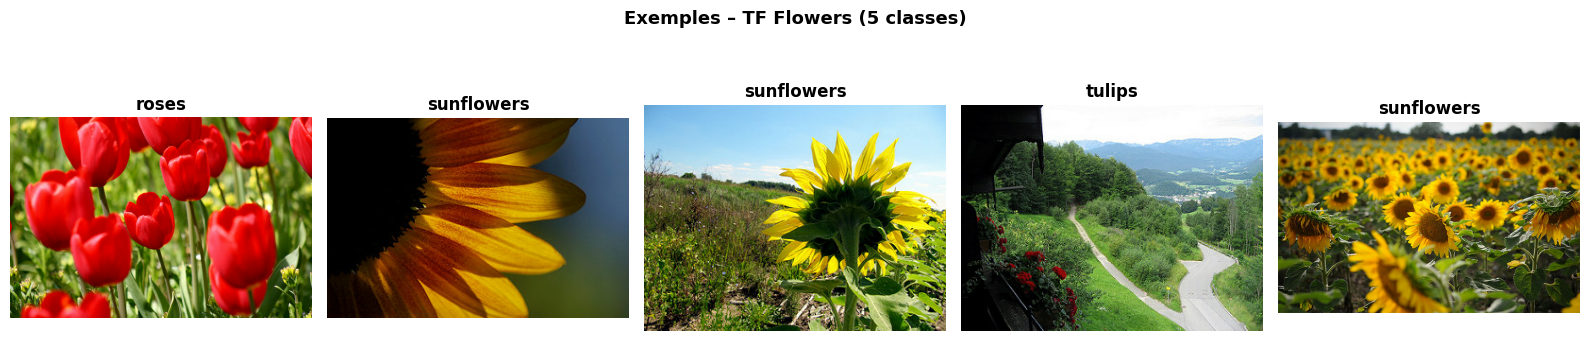

✓ flowers_exemples.png sauvegardé

TECHNIQUE A — Extraction de caractéristiques
  Toutes les couches ResNet50 sont GELÉES
  Paramètres entraînables   : 0
  Paramètres non-entraînables : 23,587,712

Entraînement Phase A (extraction de caractéristiques)...
Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 35s 272ms/step - accuracy: 0.7676 - loss: 0.6783 - val_accuracy: 0.8893 - val_loss: 0.3060 - learning_rate: 0.0010
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - accuracy: 0.9027 - loss: 0.2821 - val_accuracy: 0.9056 - val_loss: 0.2585 - learning_rate: 0.0010
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 145ms/step - accuracy: 0.9214 - loss: 0.2284 - val_accuracy: 0.9256 - val_loss: 0.2260 - learning_rate: 0.0010
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.9385 - loss: 0.1803 - val_accuracy: 0.9074 - val_loss: 0.2582 - learning_rate: 0.0010
Epoch 5/20
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9513 - loss: 0.1392
Epoch 5: ReduceLROnPlateau reducing learning rat

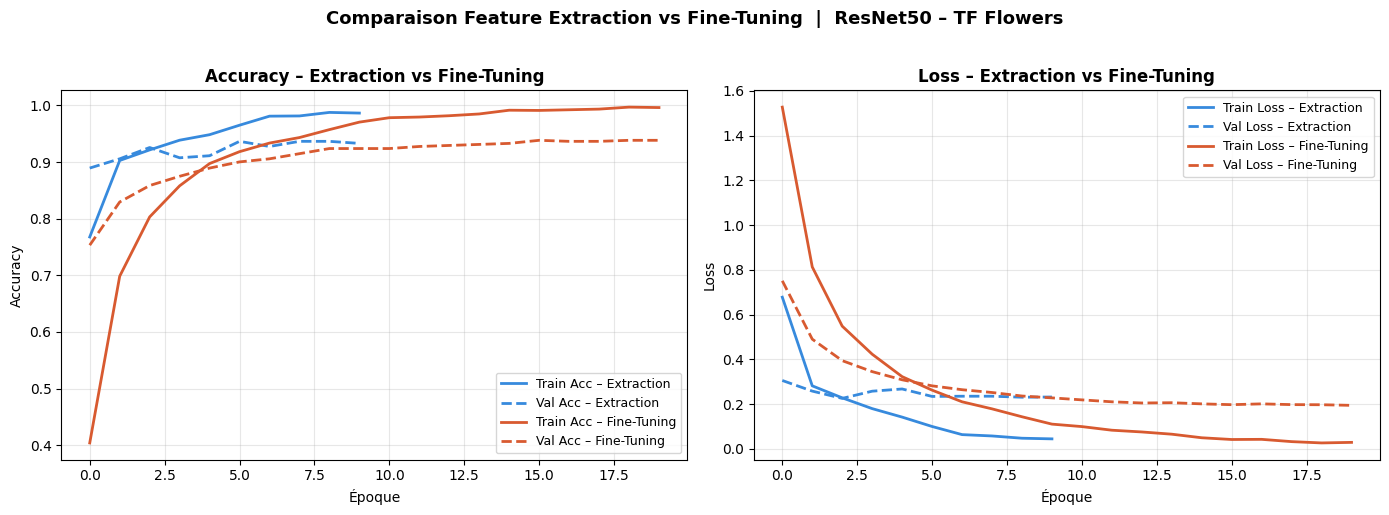

✓ comparaison_courbes.png sauvegardé


DIAGNOSTIC AUTOMATIQUE

  [Feature Extraction]
    Meilleure Train Acc : 98.75%
    Meilleure Val Acc   : 93.65%
    Écart Train-Val     : 5.11%
    Diagnostic          : BON APPRENTISSAGE – généralisation satisfaisante

  [Fine-Tuning]
    Meilleure Train Acc : 99.69%
    Meilleure Val Acc   : 93.83%
    Écart Train-Val     : 5.86%
    Diagnostic          : BON APPRENTISSAGE – généralisation satisfaisante

  → Meilleure technique sur le test : Fine-Tuning
  → Gain de précision : +0.91%

  Interprétation (cours GOMYCODE) :
  • Feature Extraction : rapide, peu coûteux, couches gelées,
    idéal quand données cibles ≈ données source et dataset petit
  • Fine-Tuning : plus flexible, précision supérieure possible,
    nécessite LR faible (1e-5) pour préserver poids pré-entraînés


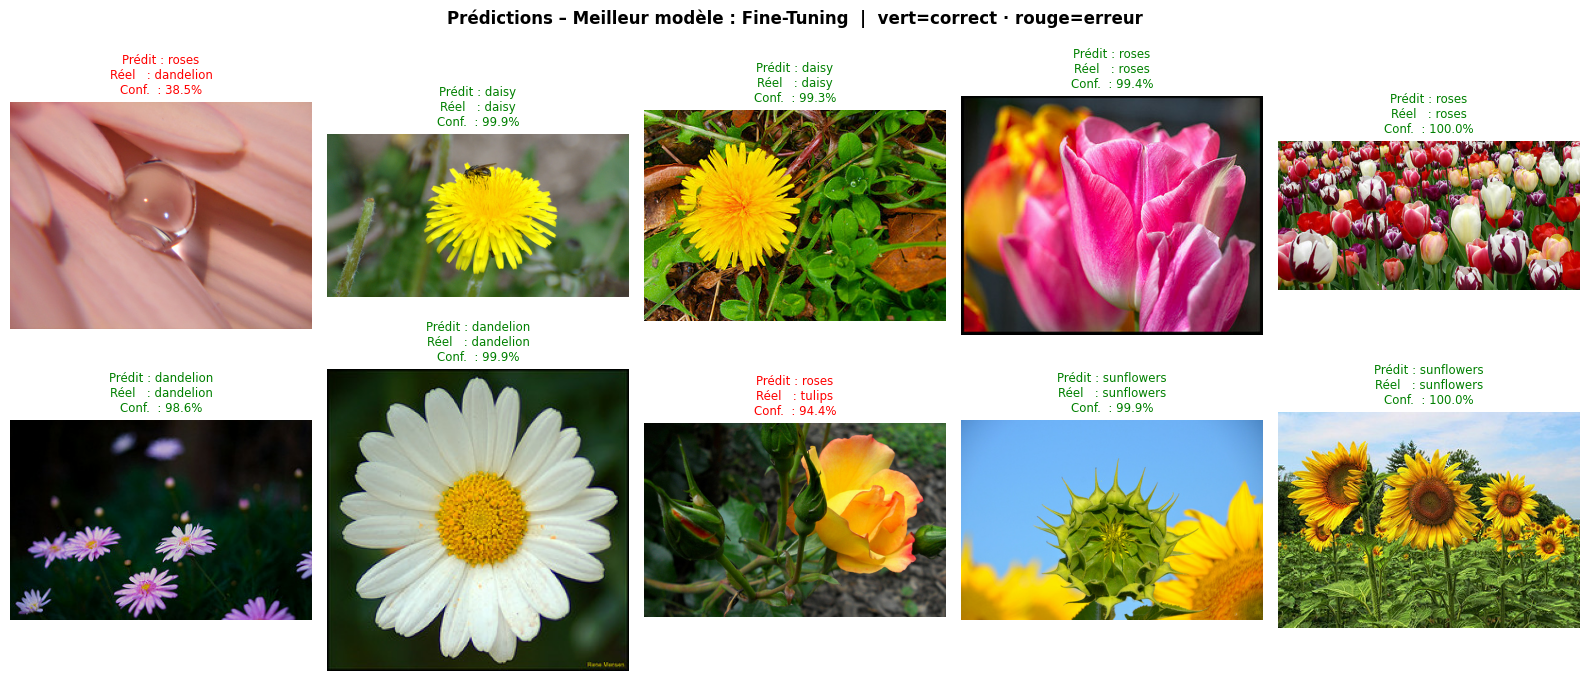

✓ predictions_test.png sauvegardé

✓ Modèle sauvegardé : resnet50_flowers_best.keras (Fine-Tuning)

RÉCAPITULATIF – Feature Extraction vs Fine-Tuning
  Dataset    : TF Flowers (5 classes, 3670 images)
  Backbone   : ResNet50 (pré-entraîné ImageNet)
  Tête       : GAP → Dense(256) → Dropout(0.5) → Softmax(5)

  ┌─────────────────────────┬──────────┬──────────┐
  │ Technique               │ Test Acc │ LR       │
  ├─────────────────────────┼──────────┼──────────┤
  │ Feature Extraction      │  92.18%  │  1e-3    │
  │ Fine-Tuning (block5)    │  93.09%  │  1e-5    │
  └─────────────────────────┴──────────┴──────────┘

CONCLUSIONS (selon cours GOMYCODE) :
  1. Extraction de caractéristiques :
     → Couches ResNet50 GELÉES — vecteur de caractéristiques figé
     → Rapide, moins coûteux, risque d'overfitting si peu de données
     → Adapté quand tâche cible similaire à tâche source

  2. Fine-Tuning :
     → Couches supérieures (block5) DÉCONGELÉES — paramètres adaptés
     → LR très faible

In [9]:
#  CHECKPOINT : Feature Extraction vs. Fine-Tuning
#  Modèle pré-entraîné : ResNet50 (ImageNet)
#  Jeu de données : TensorFlow Flowers (5 classes : daisy, dandelion,
#                   roses, sunflowers, tulips)
#  Basé sur le cours GOMYCODE – Feature Extraction vs. Fine-Tuning
#
#  STRUCTURE DU SCRIPT
#  ─────────────────────────────────────────────────────────────────────
#  0. Imports & configuration
#  1. Chargement et prétraitement du jeu de données (Flowers / 5 classes)
#  2. Visualisation des exemples
#  3. TECHNIQUE A — Extraction de caractéristiques (toutes couches gelées)
#  4. TECHNIQUE B — Fine-Tuning (N dernières couches débloquées)
#  5. Comparaison des courbes d'apprentissage
#  6. Évaluation finale et diagnostic
#  7. Prédictions visuelles sur le jeu de test
#  8. Sauvegarde du meilleur modèle

# 0. IMPORTS & CONFIGURATION
# ─────────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow_datasets as tfds

tf.random.set_seed(42)
np.random.seed(42)

print("=" * 60)
print("Feature Extraction vs. Fine-Tuning  |  ResNet50  |  Flowers")
print("=" * 60)
print(f"TensorFlow : {tf.__version__}")
print(f"GPU disponible : {tf.config.list_physical_devices('GPU')}\n")

# Hyperparamètres communs
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5
CLASS_NAMES = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

# ─────────────────────────────────────────────
# 1. CHARGEMENT DU JEU DE DONNÉES : TF Flowers
#    5 classes de fleurs — petit dataset réaliste
#    → contexte idéal pour comparer les 2 techniques
# ─────────────────────────────────────────────
(ds_train_raw, ds_val_raw, ds_test_raw), info = tfds.load(
    'tf_flowers',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised=True,
    with_info=True,
)

n_train = ds_train_raw.cardinality().numpy()
n_val   = ds_val_raw.cardinality().numpy()
n_test  = ds_test_raw.cardinality().numpy()

print(f"Jeu de données : TF Flowers (5 classes)")
print(f"  Train : {n_train} | Val : {n_val} | Test : {n_test}")
print(f"  Classes : {CLASS_NAMES}\n")

# ─────────────────────────────────────────────
# 2. PRÉTRAITEMENT
#    • preprocess_input ResNet50 (normalisation ImageNet [-1, 1])
#    • Augmentation légère uniquement sur le train
# ─────────────────────────────────────────────
def preprocess(img, label):
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = keras.applications.resnet50.preprocess_input(img)
    return img, label

def augment(img, label):
    img, label = preprocess(img, label)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, label

AUTOTUNE = tf.data.AUTOTUNE

ds_train = (ds_train_raw
            .map(augment, num_parallel_calls=AUTOTUNE)
            .shuffle(800).batch(BATCH_SIZE).prefetch(AUTOTUNE))

ds_val = (ds_val_raw
          .map(preprocess, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE).prefetch(AUTOTUNE))

ds_test = (ds_test_raw
           .map(preprocess, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE).prefetch(AUTOTUNE))

# ─────────────────────────────────────────────
# 2b. VISUALISATION DES EXEMPLES DU DATASET
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for i, (img, label) in enumerate(ds_train_raw.take(5)):
    ax = axes[i]
    ax.imshow(img.numpy())
    ax.set_title(CLASS_NAMES[label.numpy()], fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('Exemples – TF Flowers (5 classes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('flowers_exemples.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ flowers_exemples.png sauvegardé\n")

# ─────────────────────────────────────────────
# 3. TECHNIQUE A — EXTRACTION DE CARACTÉRISTIQUES
# ─────────────────────────────────────────────
# Selon le cours :
#   • Paramètres du modèle pré-entraîné MAINTENUS FIGÉS
#   • On entraîne uniquement la nouvelle tête de classification
#   • Utile quand dataset cible est PETIT ou ressources limitées
#   • Moins coûteux en calcul que le fine-tuning
# ─────────────────────────────────────────────
print("=" * 60)
print("TECHNIQUE A — Extraction de caractéristiques")
print("  Toutes les couches ResNet50 sont GELÉES")
print("=" * 60)

# 3a. Charger ResNet50 sans tête
base_A = ResNet50(weights='imagenet', include_top=False,
                  input_shape=(*IMG_SIZE, 3))
base_A.trainable = False   # ← GEL TOTAL : aucun paramètre modifié

print(f"  Paramètres entraînables   : "
      f"{sum(np.prod(w.shape) for w in base_A.trainable_weights):,}")
print(f"  Paramètres non-entraînables : "
      f"{sum(np.prod(w.shape) for w in base_A.non_trainable_weights):,}")

# 3b. Ajouter la tête de classification
#     Architecture : GAP → Dense(256) → Dropout(0.5) → Softmax
inp_A = keras.Input(shape=(*IMG_SIZE, 3))
x_A   = base_A(inp_A, training=False)   # training=False → BN en inférence
x_A   = layers.GlobalAveragePooling2D()(x_A)
x_A   = layers.Dense(256, activation='relu')(x_A)
x_A   = layers.Dropout(0.5)(x_A)
out_A = layers.Dense(NUM_CLASSES, activation='softmax')(x_A)

model_A = keras.Model(inp_A, out_A, name='ResNet50_FeatureExtraction')

# 3c. Compilation + entraînement
model_A.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_A = [
    EarlyStopping(monitor='val_accuracy', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
]

print("\nEntraînement Phase A (extraction de caractéristiques)...")
history_A = model_A.fit(
    ds_train, validation_data=ds_val,
    epochs=20, callbacks=callbacks_A, verbose=1
)

loss_A, acc_A = model_A.evaluate(ds_test, verbose=0)
print(f"\n✓ Technique A – Test Accuracy : {acc_A*100:.2f}%  | Loss : {loss_A:.4f}")

# ─────────────────────────────────────────────
# 4. TECHNIQUE B — FINE-TUNING
# ─────────────────────────────────────────────
# Selon le cours :
#   • On DÉCONGÈLE les N dernières couches du modèle de base
#   • Entraînement CONJOINT : dernières couches base + nouvelle tête
#   • Permet d'adapter les représentations profondes à la tâche cible
#   • Plus flexible, meilleure précision potentielle
#   • Nécessite plus de ressources et un LR plus faible
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("TECHNIQUE B — Fine-Tuning")
print("  Dernières couches ResNet50 DÉBLOQUÉES (block5)")
print("=" * 60)

# 4a. Charger ResNet50 sans tête
base_B = ResNet50(weights='imagenet', include_top=False,
                  input_shape=(*IMG_SIZE, 3))

# 4b. Afficher les couches pour identifier le point de dégel
print("\nCouches ResNet50 (dernières 10) :")
for i, layer in enumerate(base_B.layers[-10:]):
    idx = len(base_B.layers) - 10 + i
    print(f"  [{idx:3d}] {layer.name}")

# 4c. Dégel progressif : garder gelées les couches 0..FINE_TUNE_AT-1
#     On débloque à partir de la couche 143 (début du block5 ResNet50)
FINE_TUNE_AT = 143
base_B.trainable = True
for layer in base_B.layers[:FINE_TUNE_AT]:
    layer.trainable = False

n_trainable   = sum(np.prod(w.shape) for w in base_B.trainable_weights)
n_frozen      = sum(np.prod(w.shape) for w in base_B.non_trainable_weights)
print(f"\n  Couches débloquées à partir de : {FINE_TUNE_AT}")
print(f"  Paramètres entraînables   : {n_trainable:,}")
print(f"  Paramètres non-entraînables : {n_frozen:,}")

# 4d. Même architecture de tête que Technique A (comparaison équitable)
inp_B = keras.Input(shape=(*IMG_SIZE, 3))
x_B   = base_B(inp_B, training=False)
x_B   = layers.GlobalAveragePooling2D()(x_B)
x_B   = layers.Dense(256, activation='relu')(x_B)
x_B   = layers.Dropout(0.5)(x_B)
out_B = layers.Dense(NUM_CLASSES, activation='softmax')(x_B)

model_B = keras.Model(inp_B, out_B, name='ResNet50_FineTuning')

# 4e. Compilation avec LR beaucoup plus faible (cours : éviter d'écraser
#     les poids pré-entraînés)
model_B.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),   # LR × 100 plus faible
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_B = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1),
]

print("\nEntraînement Phase B (fine-tuning)...")
history_B = model_B.fit(
    ds_train, validation_data=ds_val,
    epochs=20, callbacks=callbacks_B, verbose=1
)

loss_B, acc_B = model_B.evaluate(ds_test, verbose=0)
print(f"\n✓ Technique B – Test Accuracy : {acc_B*100:.2f}%  | Loss : {loss_B:.4f}")

# ─────────────────────────────────────────────
# 5. COMPARAISON DES COURBES D'APPRENTISSAGE
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

COLOR_A = '#378ADD'   # bleu   → Extraction
COLOR_B = '#D85A30'   # orange → Fine-Tuning

# ── Accuracy ──────────────────────────────────
axes[0].plot(history_A.history['accuracy'],     color=COLOR_A,
             label='Train Acc – Extraction', linewidth=2)
axes[0].plot(history_A.history['val_accuracy'], color=COLOR_A,
             linestyle='--', label='Val Acc – Extraction', linewidth=2)
axes[0].plot(history_B.history['accuracy'],     color=COLOR_B,
             label='Train Acc – Fine-Tuning', linewidth=2)
axes[0].plot(history_B.history['val_accuracy'], color=COLOR_B,
             linestyle='--', label='Val Acc – Fine-Tuning', linewidth=2)
axes[0].set_title('Accuracy – Extraction vs Fine-Tuning',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Loss ──────────────────────────────────────
axes[1].plot(history_A.history['loss'],     color=COLOR_A,
             label='Train Loss – Extraction', linewidth=2)
axes[1].plot(history_A.history['val_loss'], color=COLOR_A,
             linestyle='--', label='Val Loss – Extraction', linewidth=2)
axes[1].plot(history_B.history['loss'],     color=COLOR_B,
             label='Train Loss – Fine-Tuning', linewidth=2)
axes[1].plot(history_B.history['val_loss'], color=COLOR_B,
             linestyle='--', label='Val Loss – Fine-Tuning', linewidth=2)
axes[1].set_title('Loss – Extraction vs Fine-Tuning',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparaison Feature Extraction vs Fine-Tuning  |  ResNet50 – TF Flowers',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparaison_courbes.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ comparaison_courbes.png sauvegardé\n")

# ─────────────────────────────────────────────
# 6. ÉVALUATION FINALE ET DIAGNOSTIC
# ─────────────────────────────────────────────
def diagnostiquer(history, nom):
    """Analyse overfitting / underfitting selon les courbes."""
    train_acc = max(history.history['accuracy'])
    val_acc   = max(history.history['val_accuracy'])
    ecart     = train_acc - val_acc

    print(f"\n  [{nom}]")
    print(f"    Meilleure Train Acc : {train_acc*100:.2f}%")
    print(f"    Meilleure Val Acc   : {val_acc*100:.2f}%")
    print(f"    Écart Train-Val     : {ecart*100:.2f}%")

    if train_acc < 0.65:
        verdict = "SOUS-APPRENTISSAGE – modèle trop simple ou LR inadapté"
    elif ecart > 0.15:
        verdict = "SURAPPRENTISSAGE – écart Train/Val > 15%, régulariser"
    elif val_acc > 0.80:
        verdict = "BON APPRENTISSAGE – généralisation satisfaisante"
    else:
        verdict = "CORRECT – des améliorations restent possibles"

    print(f"    Diagnostic          : {verdict}")
    return val_acc

print("\n" + "=" * 60)
print("DIAGNOSTIC AUTOMATIQUE")
print("=" * 60)
va_A = diagnostiquer(history_A, "Feature Extraction")
va_B = diagnostiquer(history_B, "Fine-Tuning")

gagnant = "Fine-Tuning" if acc_B >= acc_A else "Feature Extraction"
gain    = abs(acc_B - acc_A) * 100

print(f"\n  → Meilleure technique sur le test : {gagnant}")
print(f"  → Gain de précision : +{gain:.2f}%")
print(f"\n  Interprétation (cours GOMYCODE) :")
print(f"  • Feature Extraction : rapide, peu coûteux, couches gelées,")
print(f"    idéal quand données cibles ≈ données source et dataset petit")
print(f"  • Fine-Tuning : plus flexible, précision supérieure possible,")
print(f"    nécessite LR faible (1e-5) pour préserver poids pré-entraînés")

# ─────────────────────────────────────────────
# 7. PRÉDICTIONS VISUELLES SUR LE JEU DE TEST
#    Meilleur modèle (Fine-Tuning si acc_B >= acc_A)
# ─────────────────────────────────────────────
best_model = model_B if acc_B >= acc_A else model_A
best_name  = "Fine-Tuning" if acc_B >= acc_A else "Feature Extraction"

fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for i, (img_raw, true_label) in enumerate(ds_test_raw.take(10)):
    img_p = tf.image.resize(img_raw, IMG_SIZE)
    img_p = tf.cast(img_p, tf.float32)
    img_p = keras.applications.resnet50.preprocess_input(img_p)
    probs = best_model.predict(tf.expand_dims(img_p, 0), verbose=0)[0]
    pred  = np.argmax(probs)
    conf  = probs[pred] * 100

    ax = axes[i // 5][i % 5]
    ax.imshow(img_raw.numpy())
    color = 'green' if pred == true_label.numpy() else 'red'
    ax.set_title(
        f"Prédit : {CLASS_NAMES[pred]}\n"
        f"Réel   : {CLASS_NAMES[true_label.numpy()]}\n"
        f"Conf.  : {conf:.1f}%",
        fontsize=8.5, color=color
    )
    ax.axis('off')

plt.suptitle(f'Prédictions – Meilleur modèle : {best_name}  |  vert=correct · rouge=erreur',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions_test.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ predictions_test.png sauvegardé\n")

# ─────────────────────────────────────────────
# 8. SAUVEGARDE DU MEILLEUR MODÈLE
# ─────────────────────────────────────────────
best_model.save('resnet50_flowers_best.keras')
print(f"✓ Modèle sauvegardé : resnet50_flowers_best.keras ({best_name})\n")


# ─────────────────────────────────────────────
# RÉCAPITULATIF FINAL
# ─────────────────────────────────────────────
print("=" * 60)
print("RÉCAPITULATIF – Feature Extraction vs Fine-Tuning")
print("=" * 60)
print(f"  Dataset    : TF Flowers (5 classes, {n_train+n_val+n_test} images)")
print(f"  Backbone   : ResNet50 (pré-entraîné ImageNet)")
print(f"  Tête       : GAP → Dense(256) → Dropout(0.5) → Softmax(5)")
print()
print(f"  ┌─────────────────────────┬──────────┬──────────┐")
print(f"  │ Technique               │ Test Acc │ LR       │")
print(f"  ├─────────────────────────┼──────────┼──────────┤")
print(f"  │ Feature Extraction      │ {acc_A*100:6.2f}%  │  1e-3    │")
print(f"  │ Fine-Tuning (block5)    │ {acc_B*100:6.2f}%  │  1e-5    │")
print(f"  └─────────────────────────┴──────────┴──────────┘")
print()
print("CONCLUSIONS (selon cours GOMYCODE) :")
print("  1. Extraction de caractéristiques :")
print("     → Couches ResNet50 GELÉES — vecteur de caractéristiques figé")
print("     → Rapide, moins coûteux, risque d'overfitting si peu de données")
print("     → Adapté quand tâche cible similaire à tâche source")
print()
print("  2. Fine-Tuning :")
print("     → Couches supérieures (block5) DÉCONGELÉES — paramètres adaptés")
print("     → LR très faible (1e-5) pour préserver connaissances pré-entraînées")
print("     → Plus flexible, meilleure précision potentielle")
print("     → Backpropagation met à jour plus de paramètres → plus lent")
print()
print("  Choix optimal = f(taille dataset, similarité, ressources, précision cible)")


